# Module 01 — RSLC Fundamentals

**File used:** `NISAR_L1_PR_RSLC_025_034_D_073_2005_DHDH_M_20260710T133917_20260710T133952_P05023_N_F_J_001.h5`

**Product / band:** RSLC (L1), L-band, track 034 / frame 073, descending pass, acquired 2026-07-10T13:39:17–13:39:52 UTC.

**Why this file:** it is the earlier of the two repeat-pass acquisitions used across this tutorial (paired with File 2 in Module 02, and used as the InSAR *reference* acquisition in Module 04's GUNW product). This module focuses on it alone to introduce the RSLC product structure: complex SLC data, amplitude/phase separation, multilooking, and speckle statistics.

**Region:** confirmed below directly from this file's `identification/boundingPolygon` metadata (not assumed) — see the next code cell.

## Scope & Caveats

This notebook demonstrates **RSLC data-reading and speckle-statistics techniques** using one real NISAR acquisition. It is not a validated study of any specific land-cover class, crop type, or ground condition in this scene — no ground truth has been collected or compared against. The backscatter/speckle behavior shown here illustrates the *technique*, not a claim about what is physically happening at any particular pixel.

Geographic description below is strictly technical (terrain/elevation derived from metadata).

## Theory recap

This module puts two ideas from **Module 00** into practice with real data:

- **Section 4 (the complex SLC pixel)**: every pixel below is a complex number `z = amplitude x exp(i x phase)`; we read it directly from the RSLC product and split it into amplitude and phase.
- **Section 5 (speckle)**: theory predicts single-look intensity has coefficient of variation (CV) ~1.0, dropping to ~1/sqrt(N) for N looks. Module 00 verified this on idealized synthetic speckle; below we check it against real data, which -- as you'll see -- doesn't match the idealized curve as cleanly, and we work out why.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SAMPLE_DATA_DIR = REPO_ROOT / "SampleData"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from nisar_tools.io import open_product
from nisar_tools import preprocess as prep
from nisar_tools import viz

plt.rcParams["figure.dpi"] = 100

In [2]:
RSLC1_PATH = SAMPLE_DATA_DIR / "NISAR_L1_PR_RSLC_025_034_D_073_2005_DHDH_M_20260710T133917_20260710T133952_P05023_N_F_J_001.h5"

rslc1 = open_product(RSLC1_PATH)

print("Product type:        ", rslc1.product_type)
print(f"Band group:            science/{rslc1.band_group}/...")
print("Radar band:           ", rslc1.radar_band)
print("Track / frame:        ", rslc1.track_number, "/", rslc1.frame_number)
print("Orbit direction:      ", rslc1.orbit_pass_direction)
print("Acquisition (UTC):    ", rslc1.zero_doppler_start_time, "->", rslc1.zero_doppler_end_time)
print("Frequencies:          ", rslc1.list_of_frequencies)
print("Freq A polarizations: ", rslc1.list_polarizations("A"))

bbox = rslc1.bbox
print("\nRegion (from boundingPolygon metadata, not assumed):")
print(f"  lon {bbox['lon_min']:.2f} to {bbox['lon_max']:.2f} deg E")
print(f"  lat {bbox['lat_min']:.2f} to {bbox['lat_max']:.2f} deg N")
print(f"  polygon vertex elevations {bbox['height_min']:.0f} to {bbox['height_max']:.0f} m")
print(
    "\nThis spans northwestern India: agricultural plains at the lower-elevation "
    "polygon vertices, rising into Himalayan foothill terrain at the higher-elevation "
    "vertices (consistent with docs/data_inventory.md)."
)

Product type:         RSLC
Band group:            science/LSAR/...
Radar band:            L
Track / frame:         34 / 73
Orbit direction:       Descending
Acquisition (UTC):     2026-07-10T13:39:17.000000000 -> 2026-07-10T13:39:52.999342105
Frequencies:           ['A', 'B']
Freq A polarizations:  ['HH', 'HV']

Region (from boundingPolygon metadata, not assumed):
  lon 74.84 to 78.16 deg E
  lat 29.37 to 32.13 deg N
  polygon vertex elevations 156 to 2930 m

This spans northwestern India: agricultural plains at the lower-elevation polygon vertices, rising into Himalayan foothill terrain at the higher-elevation vertices (consistent with docs/data_inventory.md).


## Reading the complex SLC

The RSLC image cube (`swaths/frequencyA/HH`) is a complex64 array of shape (54720 azimuth lines x 26704 range samples) — about 10.9 GB. `nisar_tools.io` never loads this whole array into memory; `read_slc_block` slices a bounded window directly out of the HDF5 dataset. We take a window near the scene center for the demonstrations below.

In [3]:
dset = rslc1.get_slc_dataset("A", "HH")
n_rows, n_cols = dset.shape
print("Full frequencyA/HH shape:", dset.shape, "(", round(dset.size * dset.dtype.itemsize / 1e9, 1), "GB )")

row_slice, col_slice = prep.center_window(n_rows, n_cols, 1500, 1500)
slc_window = rslc1.read_slc_block("A", "HH", row_slice, col_slice)
print("Window shape read into memory:", slc_window.shape, slc_window.dtype)

amp = prep.amplitude(slc_window)
phase = np.angle(slc_window)

Full frequencyA/HH shape: (54720, 26704) ( 11.7 GB )
Window shape read into memory: (1500, 1500) complex64


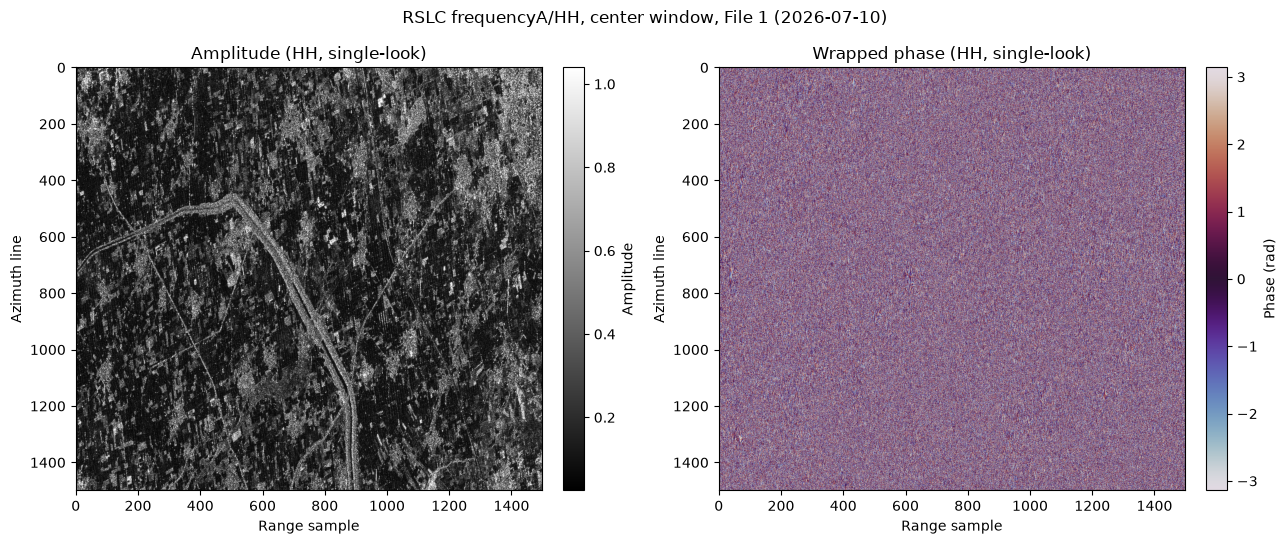

In [4]:
fig, axes = viz.new_figure(ncols=2)
viz.imshow_amplitude(axes[0], amp, title="Amplitude (HH, single-look)")
viz.imshow_phase(axes[1], phase, title="Wrapped phase (HH, single-look)")
fig.suptitle("RSLC frequencyA/HH, center window, File 1 (2026-07-10)")
fig.tight_layout()
plt.show()

## Speckle and multilooking

SLC amplitude/intensity carries speckle: multiplicative noise from coherent summation of many sub-resolution scatterers within each pixel. For *fully developed* speckle over a single homogeneous target, single-look intensity has a coefficient of variation (std/mean) of approximately 1.0, and incoherently averaging N independent looks reduces that to approximately 1/sqrt(N).

The center window plotted above is visibly **not** homogeneous — it mixes agricultural fields, field boundaries, and a linear water/road feature, so its overall CV reflects real backscatter variability between those classes as well as speckle. To check the speckle-statistics theory cleanly, we first search the window for its most homogeneous sub-patch (lowest 1-look CV), then run the multilook comparison specifically on that patch.

In [5]:
power_1look = prep.power(slc_window)

patch_size = 320
stride = 80

best_cv = np.inf
best_rc = (0, 0)
for r0 in range(0, power_1look.shape[0] - patch_size + 1, stride):
    for c0 in range(0, power_1look.shape[1] - patch_size + 1, stride):
        patch = power_1look[r0:r0 + patch_size, c0:c0 + patch_size]
        cv = prep.coefficient_of_variation(patch)
        if cv < best_cv:
            best_cv, best_rc = cv, (r0, c0)

r0, c0 = best_rc
print(f"Most homogeneous {patch_size}x{patch_size} sub-patch: row={r0}, col={c0}, 1-look power CV={best_cv:.3f}")
homog_power = power_1look[r0:r0 + patch_size, c0:c0 + patch_size]

Most homogeneous 320x320 sub-patch: row=960, col=560, 1-look power CV=2.152


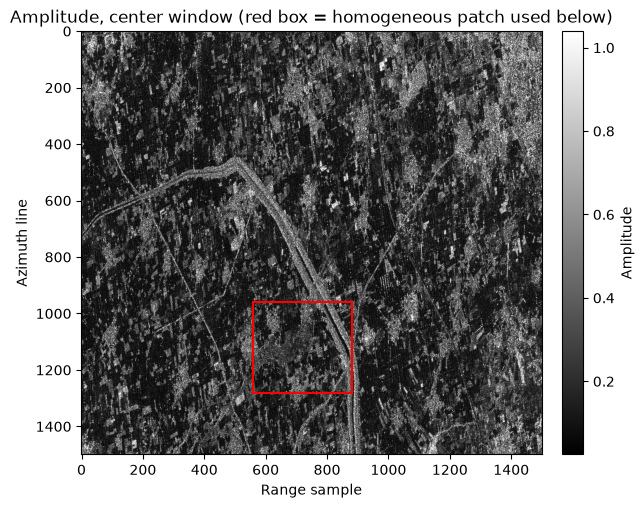

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
viz.imshow_amplitude(ax, amp, title="Amplitude, center window (red box = homogeneous patch used below)")
ax.add_patch(patches.Rectangle((c0, r0), patch_size, patch_size, linewidth=1.5, edgecolor="red", facecolor="none"))
plt.show()

In [7]:
print(f"1-look power CV (homogeneous patch):  {prep.coefficient_of_variation(homog_power):.3f}   (theory: ~1.000)")

for looks in (2, 4, 8):
    power_ml = prep.multilook(homog_power, looks, looks)
    n_looks_total = looks * looks
    expected_cv = 1.0 / np.sqrt(n_looks_total)
    print(
        f"{looks}x{looks} multilook ({n_looks_total:3d} looks) power CV: "
        f"{prep.coefficient_of_variation(power_ml):.3f}   (theory: ~{expected_cv:.3f})"
    )

1-look power CV (homogeneous patch):  2.152   (theory: ~1.000)
2x2 multilook (  4 looks) power CV: 1.587   (theory: ~0.500)
4x4 multilook ( 16 looks) power CV: 1.184   (theory: ~0.250)
8x8 multilook ( 64 looks) power CV: 0.917   (theory: ~0.125)


The CV decreases monotonically with more looks, as expected, but starts above 1.0 and decays more slowly than the idealized 1/sqrt(N) curve would predict. This is a realistic result, not a bug: fully-developed, purely random speckle statistics (CV -> 1/sqrt(N) exactly) are an idealization for a single uniform point target. Real agricultural terrain — even in whichever sub-patch minimizes CV within our search window — still carries some spatially-correlated texture (field microstructure, furrow/moisture patterns, a faint field-boundary feature visible in the zoomed image below) that multilooking does not remove the way it removes independent speckle noise. The qualitative trend (fewer, larger, smoother patches with more looks) is what the visual comparison below is meant to show — treat the exact CV numbers as illustrative, not a precision validation of speckle theory.

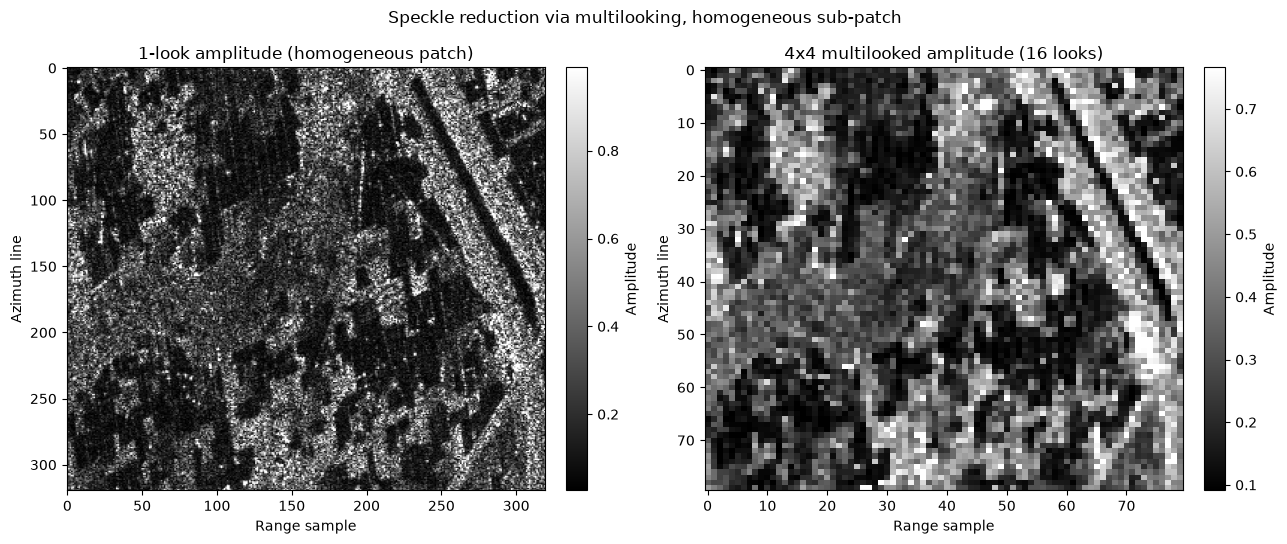

In [8]:
homog_power_4x4 = prep.multilook(homog_power, 4, 4)
homog_amp = np.sqrt(homog_power)
homog_amp_4x4 = np.sqrt(homog_power_4x4)

fig, axes = viz.new_figure(ncols=2)
viz.imshow_amplitude(axes[0], homog_amp, title="1-look amplitude (homogeneous patch)")
viz.imshow_amplitude(axes[1], homog_amp_4x4, title="4x4 multilooked amplitude (16 looks)")
fig.suptitle("Speckle reduction via multilooking, homogeneous sub-patch")
fig.tight_layout()
plt.show()

In [9]:
rslc1.close()

## What real-world deployment would additionally require

- A validated reason to look at this specific scene/date (a documented event, monitoring requirement, or research question) rather than an arbitrary center window chosen for demonstration.
- Radiometric calibration to a physical backscatter unit (sigma-nought/gamma-nought) using the product's `calibrationInformation`, not raw complex-SLC amplitude, before any cross-scene or cross-date quantitative comparison.
- Ground truth (field surveys, higher-resolution optical imagery, or in-situ measurements) to interpret what any backscatter or speckle pattern actually corresponds to on the ground.
- Processing the full image (or a systematically chosen area of interest), not a single demo window, and homogeneity/patch selection done for a real analytical purpose rather than to validate speckle theory.